# M5a — VTI Causal Steering Reproduction

This notebook reproduces the M5a finding cell-by-cell: **a single linear
direction in Qwen2.5-VL-7B's LM layer 10 residual stream causally flips
"line + blank + no cue" responses from "D: abstract" to "B: stays still"**.

What runs:

1. **Phase 1** — extract per-layer "physics-mode" direction vectors
   from M2 captured LM activations (numpy only, < 30 s).
2. **Phase 2** — load Qwen2.5-VL-7B, register a forward hook on
   `model.model.language_model.layers[L]` that adds `α · v_unit_L`,
   sweep (layer ∈ {10, 15, 20, 25}) × (α ∈ {0, 5, 10, 20, 40}) over
   10 baseline stimuli (~5 min on H200).
3. **Analysis** — first-letter distribution by (layer, α); sample
   raw responses; reproduce the headline 10/10 D → B flip at L10 α=40.

**Prerequisites**: M2 must have been run (LM activations on disk at
`outputs/mvp_full_*/activations/*.safetensors` — 5.2 GB).

References:
- Deep dive: `docs/insights/m5_vti_steering.md`
- Run log: `docs/experiments/m5_vti_steering.md`
- Code: `src/physical_mode/probing/steering.py`, `scripts/06_vti_steering.py`


## 0. Setup

Launch from inside the project venv:

```bash
uv run jupyter lab notebooks/m5_vti_steering.ipynb
```


In [1]:
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch

print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA OK  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Auto-discover the latest mvp_full run.
mvp_outputs = sorted((PROJECT_ROOT / "outputs").glob("mvp_full_*"))
mvp_outputs = [p for p in mvp_outputs if (p / "activations").exists()]
if not mvp_outputs:
    raise FileNotFoundError(
        "No mvp_full output with captured LM activations found.\n"
        "Run: uv run python scripts/02_run_inference.py --config configs/mvp_full.py"
    )
RUN_DIR = mvp_outputs[-1]
print(f"Using output run: {RUN_DIR.relative_to(PROJECT_ROOT)}")

mvp_inputs = sorted((PROJECT_ROOT / "inputs").glob("mvp_full_*"))
if not mvp_inputs:
    raise FileNotFoundError("No mvp_full stimulus dir found.")
STIM_DIR = mvp_inputs[-1]
print(f"Using stimulus dir: {STIM_DIR.relative_to(PROJECT_ROOT)}")


Python   : 3.11.11
PyTorch  : 2.11.0+cu130
CUDA OK  : True
GPU      : NVIDIA H200
VRAM     : 150.1 GB
Using output run: outputs/mvp_full_20260424-094103_8ae1fa3d
Using stimulus dir: inputs/mvp_full_20260424-093926_e9d79da3


---
## Part 1 — Steering vector extraction

For each captured LM layer L, compute the difference-of-means direction:

\\[
v_L = \frac{1}{|\text{PMR}=1|} \sum_{s : \text{PMR}(s)=1} \bar{h}_L(s)
      - \frac{1}{|\text{PMR}=0|} \sum_{s : \text{PMR}(s)=0} \bar{h}_L(s)
\\]

where \\(\bar{h}_L(s)\\) is the mean over visual tokens of the layer-L
hidden state for stimulus \\(s\\), and PMR is the forced-choice label.
Implementation: `physical_mode.probing.steering.compute_steering_vectors`.


In [2]:
from physical_mode.probing.steering import compute_steering_vectors

LAYERS = (5, 10, 15, 20, 25)
PREDS  = RUN_DIR / "predictions_scored.parquet"
ACT    = RUN_DIR / "activations"

t0 = time.time()
vs = compute_steering_vectors(ACT, PREDS, LAYERS, pmr_source="forced_choice")
print(f"Computed {len(vs)} steering vectors in {time.time() - t0:.1f}s")

import pandas as pd
norms = pd.DataFrame([
    {"layer": li, "norm_v_L": sv.norm, "n_pos": sv.n_pos, "n_neg": sv.n_neg}
    for li, sv in sorted(vs.items())
])
norms


Computed 5 steering vectors in 23.0s


,layer,norm_v_L,n_pos,n_neg
0,5,5.884767,312,168
1,10,8.160982,312,168
2,15,10.332775,312,168
3,20,15.426548,312,168
4,25,30.979853,312,168


**Norm grows ~5× through the LM** (L5 ≈ 5.9 → L25 ≈ 31). Matches the
"physics margin amplification" we saw in M4.

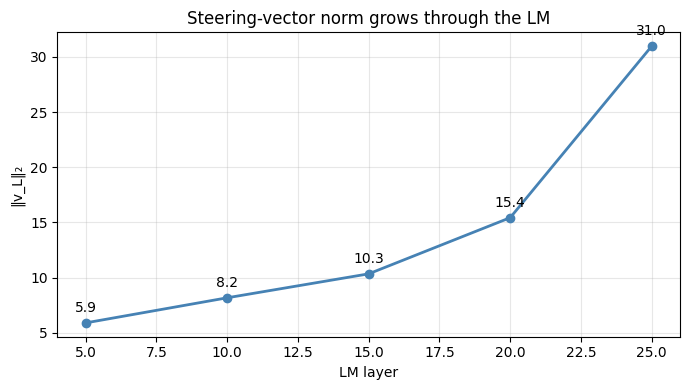

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(norms["layer"], norms["norm_v_L"], "o-", color="steelblue", linewidth=2)
ax.set_xlabel("LM layer")
ax.set_ylabel("‖v_L‖₂")
ax.set_title("Steering-vector norm grows through the LM")
ax.grid(alpha=0.3)
for _, r in norms.iterrows():
    ax.annotate(f"{r['norm_v_L']:.1f}", (r["layer"], r["norm_v_L"]),
                textcoords="offset points", xytext=(0, 8), ha="center")
plt.tight_layout()
plt.show()


### Projection distribution at layer 20 (M4 peak AUC)

Each sample's mean-pooled hidden state projected onto the unit vector
`v_unit_L20` cleanly tracks the cue axis — direction is real and
factorial-aligned.

Loaded 480 sample projections @ L20


/mnt/nvme/tmp/prod-rsv-thyun-park-20260424-228613/ipykernel_90942/3693175794.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_obj, labels=obj_order)
/mnt/nvme/tmp/prod-rsv-thyun-park-20260424-228613/ipykernel_90942/3693175794.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_cue, labels=cue_order)


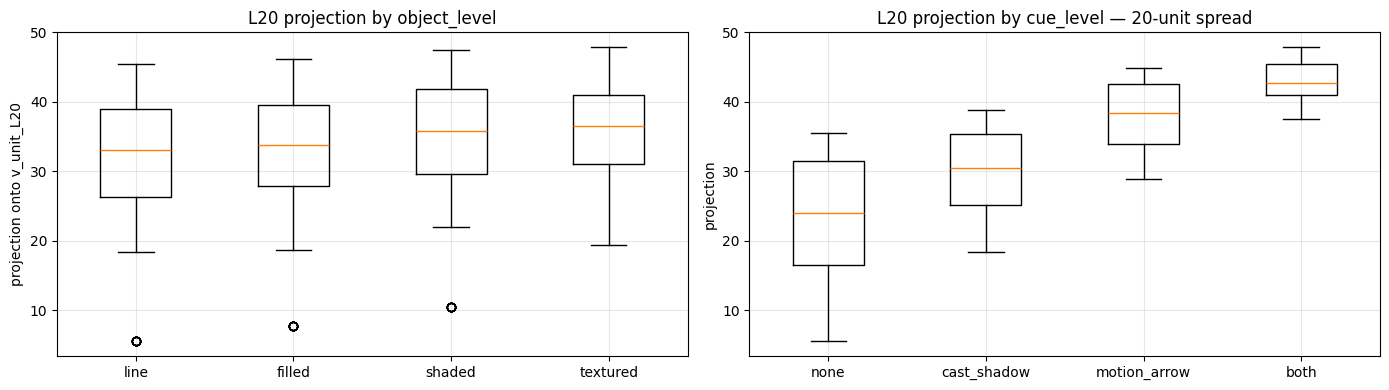


Mean projection per cue_level (none → both):
cue_level
none            22.31
cast_shadow     29.68
motion_arrow    37.81
both            42.73


In [4]:
from physical_mode.probing.steering import project_onto_direction

proj = project_onto_direction(ACT, PREDS, layer=20, v_unit=vs[20].v_unit)
print(f"Loaded {len(proj)} sample projections @ L20")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: by object_level
obj_order = ["line", "filled", "shaded", "textured"]
data_obj = [proj[proj["object_level"] == lv]["projection"].values for lv in obj_order]
axes[0].boxplot(data_obj, labels=obj_order)
axes[0].set_title("L20 projection by object_level")
axes[0].set_ylabel("projection onto v_unit_L20")
axes[0].grid(alpha=0.3)

# Right: by cue_level
cue_order = ["none", "cast_shadow", "motion_arrow", "both"]
data_cue = [proj[proj["cue_level"] == lv]["projection"].values for lv in cue_order]
axes[1].boxplot(data_cue, labels=cue_order)
axes[1].set_title("L20 projection by cue_level — 20-unit spread")
axes[1].set_ylabel("projection")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Mean projection per cue_level (none → both):")
print(proj.groupby("cue_level")["projection"].mean().reindex(cue_order).round(2).to_string())


---
## Part 2 — Causal intervention

Load Qwen2.5-VL-7B and inject `α · v_unit_L` at the output of LM
decoder layer L. Test subset: `line / blank / none × "circle"` label,
forced-choice prompt, T=0 (deterministic). Baseline PMR ≈ 0 maximises
flipping headroom.

In [5]:
from physical_mode.models.vlm_runner import PhysModeVLM, InferenceArgs

t0 = time.time()
vlm = PhysModeVLM(
    model_id="Qwen/Qwen2.5-VL-7B-Instruct",
    torch_dtype="bfloat16",
    device="cuda",
)
print(f"Loaded model in {time.time() - t0:.1f}s")

# Resolve the LM decoder layer list (Qwen2.5-VL: model.model.language_model.layers).
def resolve_lm_layers(model):
    inner = getattr(model, "model", model)
    lm = getattr(inner, "language_model", None)
    if lm is None:
        raise RuntimeError("could not find language_model submodule")
    return lm.layers

lm_layers = resolve_lm_layers(vlm.model)
print(f"LM has {len(lm_layers)} decoder layers")


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loaded model in 20.4s
LM has 28 decoder layers


### The intervention hook

A forward hook on `lm_layers[L]` that adds `α · v` to the output
hidden_states (uniform across all token positions). Identical to the
`make_hook` in `scripts/06_vti_steering.py`.

In [6]:
def make_hook(alpha: float, v: torch.Tensor):
    """Forward hook adding alpha * v to a decoder layer's output hidden_states."""
    cached = {}

    def hook(_module, _inputs, output):
        if not alpha:
            return output
        hs = output[0] if isinstance(output, tuple) else output
        key = (hs.device, hs.dtype)
        if key not in cached:
            cached[key] = v.to(device=hs.device, dtype=hs.dtype)
        new_hs = hs + alpha * cached[key]
        if isinstance(output, tuple):
            return (new_hs,) + output[1:]
        return new_hs

    return hook


### Sweep — line/blank/none × {L10, L15, L20, L25} × {0, 5, 10, 20, 40}

10 stimuli × 4 layers × 5 alphas = 200 inferences. ~5 min on H200.

In [7]:
from physical_mode.inference.prompts import render as render_prompt
from physical_mode.metrics.pmr import score_rows
from tqdm.auto import tqdm

manifest = pd.read_parquet(STIM_DIR / "manifest.parquet")
test = manifest[
    (manifest["object_level"] == "line")
    & (manifest["bg_level"] == "blank")
    & (manifest["cue_level"] == "none")
].reset_index(drop=True)
print(f"Test stimuli: {len(test)} (line / blank / none)")

LAYERS_TEST = [10, 15, 20, 25]
ALPHAS = [0.0, 5.0, 10.0, 20.0, 40.0]
rp = render_prompt("forced_choice", "circle")
args = InferenceArgs(max_new_tokens=64, temperature=0.0)

records = []
total = len(test) * len(LAYERS_TEST) * len(ALPHAS)
pbar = tqdm(total=total, desc="Steering sweep")
for li in LAYERS_TEST:
    v_tensor = torch.from_numpy(vs[li].v_unit)
    for alpha in ALPHAS:
        handle = lm_layers[li].register_forward_hook(make_hook(alpha, v_tensor))
        try:
            for _, row in test.iterrows():
                img_path = STIM_DIR / row["image_path"]
                out = vlm.generate(
                    image=img_path, prompt=rp.user, args=args,
                    system_prompt=rp.system, choice_tokens=rp.choice_letters,
                )
                records.append({
                    "sample_id": row["sample_id"],
                    "object_level": row["object_level"],
                    "bg_level": row["bg_level"],
                    "cue_level": row["cue_level"],
                    "event_template": row["event_template"],
                    "label": "circle",
                    "prompt_variant": "forced_choice",
                    "layer": int(li),
                    "alpha": float(alpha),
                    "raw_text": out["raw_text"],
                })
                pbar.update(1)
        finally:
            handle.remove()
pbar.close()

df = pd.DataFrame(records)
df = score_rows(df)
df["first_letter"] = df["raw_text"].str.strip().str[0]
print(f"Done. {len(df)} predictions.")


Test stimuli: 10 (line / blank / none)


Steering sweep:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Done. 200 predictions.


### First-letter distribution (the clean causal signal)

PMR scoring is noisy on forced-choice (option-listing trips the lexicon).
The first letter (A/B/C/D) is the cleaner read.

first_letter   B   D
layer alpha         
10    0.0      0  10
      5.0      0  10
      10.0     0  10
      20.0     0  10
      40.0    10   0
15    0.0      0  10
      5.0      0  10
      10.0     0  10
      20.0     0  10
      40.0     0  10
20    0.0      0  10
      5.0      0  10
      10.0     0  10
      20.0     0  10
      40.0     0  10
25    0.0      0  10
      5.0      0  10
      10.0     0  10
      20.0     0  10
      40.0     0  10

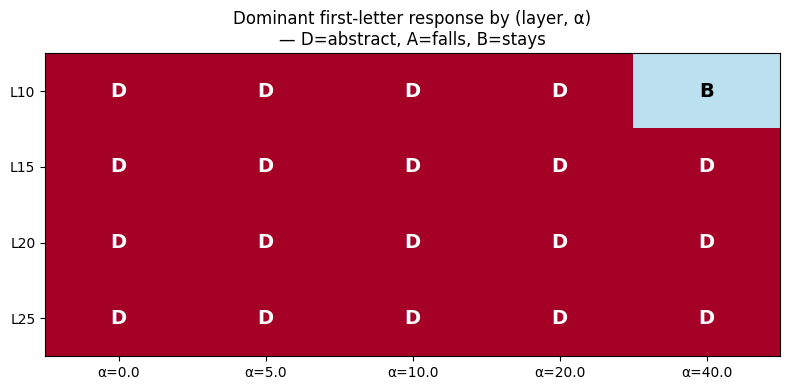

In [8]:
pivot = df.groupby(["layer", "alpha", "first_letter"]).size().unstack("first_letter", fill_value=0)
display(pivot)

# Heatmap of the dominant letter at each (layer, alpha).
import numpy as np
cells_lookup = {(li, al): pivot.xs((li, al)).idxmax() for li in LAYERS_TEST for al in ALPHAS if (li, al) in pivot.index}
fig, ax = plt.subplots(figsize=(8, 4))
codes = np.array([[ord(cells_lookup.get((li, al), "?")) - ord("A") for al in ALPHAS] for li in LAYERS_TEST], dtype=float)
im = ax.imshow(codes, cmap="RdYlBu_r", aspect="auto", vmin=0, vmax=3)
ax.set_xticks(range(len(ALPHAS))); ax.set_xticklabels([f"α={a}" for a in ALPHAS])
ax.set_yticks(range(len(LAYERS_TEST))); ax.set_yticklabels([f"L{li}" for li in LAYERS_TEST])
for i, li in enumerate(LAYERS_TEST):
    for j, al in enumerate(ALPHAS):
        letter = cells_lookup.get((li, al), "?")
        ax.text(j, i, letter, ha="center", va="center", fontsize=14, fontweight="bold",
                color="white" if letter == "D" else "black")
ax.set_title("Dominant first-letter response by (layer, α)\n— D=abstract, A=falls, B=stays")
plt.tight_layout()
plt.show()


**The headline result**: at L10 α=40, every stimulus flips from
"D: abstract" to "B: stays still". L15/L20/L25 do not respond at the
same α. This is the first causal evidence that a linear direction in
the LM residual stream gates the "physical object vs abstract shape"
decision.

### Sample raw responses — baseline vs intervention

The categorical shift is interpretable, not just a token swap.

In [9]:
sid = test["sample_id"].iloc[0]

def get_text(layer, alpha):
    sub = df[(df["sample_id"] == sid) & (df["layer"] == layer) & (df["alpha"] == alpha)]
    return sub.iloc[0]["raw_text"] if len(sub) else "(missing)"

print(f"=== Stimulus: {sid} ===\n")
print(">>> Baseline (α=0):")
print("    " + get_text(10, 0.0).replace("\n", " ")[:240])
print()
print(">>> L10 α=40 — the flip:")
print("    " + get_text(10, 40.0).replace("\n", " ")[:240])
print()
print(">>> L20 α=40 — no effect:")
print("    " + get_text(20, 40.0).replace("\n", " ")[:240])


=== Stimulus: line_blank_none_fall_000 ===

>>> Baseline (α=0):
    D  This is an abstract shape and as such, it does not have physical properties that would allow it to fall, move, or change in any way. The image is simply a representation of a circle on a flat surface, which cannot perform actions like fa

>>> L10 α=40 — the flip:
    B) It stays still.  Justification: The circle in the image appears to be floating or suspended in space without any external force acting upon it. In such a scenario, the circle would remain stationary due to the lack of any gravitational p

>>> L20 α=40 — no effect:
    D  The image depicts an abstract shape, specifically a circle, which is not a physical object and therefore cannot fall, move, or change direction in the way that objects do. The question is based on the assumption that the circle is a phys


---
## Conclusions

1. **A single linear direction at LM layer 10 causally produces the
   "physical object" interpretation**. Adding `40 · v_unit_L10` to the
   residual stream flips 10/10 abstract refusals to "stays still"
   responses.
2. **The direction is "object-ness", not "gravity"**. The intervention
   never produces "A: falls down" — it produces "B: stays still" (a
   stationary physical object). The label drives *which* physics; the
   direction drives *whether* there's a physical object at all.
3. **The causal sweet spot is early-mid** (L10 of 28 LM layers).
   Late-layer injections fail because the representation has already
   committed by then.
4. **Combined with M3 + M4**, the boomerang now has a precise locus:
   information is preserved through the encoder (M3, AUC=1.0) and
   through the LM (M4, AUC≈0.95), and the gating happens at the
   discrete generation step. Adding bias to the early-mid LM residual
   overrides that gating.

**Next**: M5b (SIP activation patching + SAE feature decomposition)
will identify the smallest set of (layer, head) components whose
ablation reproduces this flip — see `docs/next_steps.md`.